# 🎬 Notebook 4: Popularity & Churn Prediction
**Entertainment & Media Analytics Project**

Two prediction tasks using **XGBoost**:

1. **Popularity Prediction** — Predict whether a movie will be *highly rated* (avg ≥ 4.0) based on genre, release year, and rating volume features.
2. **User Churn Prediction** — Predict whether a user will become *inactive* (no ratings in the last 20% of the time window) based on their rating behaviour.

Models saved to disk — rerunning loads instead of retraining.

## 0. Setup & Seed

In [1]:
import os, warnings, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
matplotlib.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

PROCESSED_DIR = 'processed'
MODEL_DIR     = 'models'
PLOT_DIR      = 'plots'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR,  exist_ok=True)

print('Setup complete. Seed:', SEED)

Setup complete. Seed: 42


---
## 1. Load Processed Data

In [2]:
ratings      = pd.read_csv(f'{PROCESSED_DIR}/ratings_clean.csv', parse_dates=['datetime'])
movies       = pd.read_csv(f'{PROCESSED_DIR}/movies_clean.csv')
users        = pd.read_csv(f'{PROCESSED_DIR}/users_clean.csv')
movies_exp   = pd.read_csv(f'{PROCESSED_DIR}/movies_exploded.csv')

print(f'Ratings: {ratings.shape} | Movies: {movies.shape} | Users: {users.shape}')
ratings.head(3)

Ratings: (1000209, 7) | Movies: (3883, 4) | Users: (6040, 6)


,userId,movieId,rating,datetime,year,month,dayofweek
0,1,1193,5,2000-12-31 22:12:40,2000,12,Sunday
1,1,661,3,2000-12-31 22:35:09,2000,12,Sunday
2,1,914,3,2000-12-31 22:32:48,2000,12,Sunday


---
## 2. Task A — Movie Popularity Prediction
**Target:** `is_popular` = 1 if movie's average rating ≥ 4.0 AND has ≥ 50 ratings, else 0.

In [3]:
# ── Aggregate movie-level features ───────────────────────────────────────
movie_agg = (
    ratings.groupby('movieId')
    .agg(
        avg_rating   =('rating',  'mean'),
        rating_count =('rating',  'count'),
        rating_std   =('rating',  'std'),
        rating_min   =('rating',  'min'),
        rating_max   =('rating',  'max'),
    )
    .reset_index()
)
movie_agg['rating_std'] = movie_agg['rating_std'].fillna(0)

# Genre one-hot (top genres)
top_genres = movies_exp['genre'].value_counts().head(15).index.tolist()
for g in top_genres:
    movie_agg[f'genre_{g}'] = movie_agg['movieId'].isin(
        movies_exp.loc[movies_exp['genre'] == g, 'movieId']
    ).astype(int)

# Release year
movie_agg = movie_agg.merge(movies[['movieId','release_year']], on='movieId', how='left')
movie_agg['release_year'] = movie_agg['release_year'].fillna(movie_agg['release_year'].median())
movie_agg['decade']       = (movie_agg['release_year'] // 10 * 10).astype(int)

# Target
movie_agg['is_popular'] = (
    (movie_agg['avg_rating'] >= 4.0) & (movie_agg['rating_count'] >= 50)
).astype(int)

print(f'Movies: {len(movie_agg):,}')
print(f'Popular: {movie_agg["is_popular"].sum():,} ({movie_agg["is_popular"].mean():.1%})')
movie_agg.head(3)

Movies: 3,706
Popular: 330 (8.9%)


,movieId,avg_rating,rating_count,rating_std,rating_min,rating_max,genre_Drama,genre_Comedy,genre_Action,genre_Thriller,...,genre_Children's,genre_Crime,genre_War,genre_Documentary,genre_Musical,genre_Mystery,genre_Animation,release_year,decade,is_popular
0,1,4.146846,2077,0.852349,1,5,0,1,0,0,...,1,0,0,0,0,0,1,1995.0,1990,1
1,2,3.201141,701,0.983172,1,5,0,0,0,0,...,1,0,0,0,0,0,0,1995.0,1990,0
2,3,3.016736,478,1.071712,1,5,0,1,0,0,...,0,0,0,0,0,0,0,1995.0,1990,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
import xgboost as xgb

POP_FEATURES = (['rating_count','rating_std','rating_min','rating_max',
                 'release_year','decade'] +
                [f'genre_{g}' for g in top_genres])
TARGET_POP   = 'is_popular'

X_pop = movie_agg[POP_FEATURES]
y_pop = movie_agg[TARGET_POP]

X_pop_tr, X_pop_te, y_pop_tr, y_pop_te = train_test_split(
    X_pop, y_pop, test_size=0.2, random_state=SEED, stratify=y_pop
)
print(f'Pop train: {len(X_pop_tr):,}  test: {len(X_pop_te):,}')
print(f'Class balance (train): {y_pop_tr.mean():.1%} positive')

Pop train: 2,964  test: 742
Class balance (train): 8.9% positive


In [5]:
POP_MODEL_PATH = f'{MODEL_DIR}/xgb_popularity.pkl'

if os.path.exists(POP_MODEL_PATH):
    print('Loading saved popularity model...')
    pop_model = pickle.load(open(POP_MODEL_PATH, 'rb'))
else:
    print('Training XGBoost popularity model...')
    pop_model = xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 5,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        use_label_encoder= False,
        eval_metric      = 'logloss',
        random_state     = SEED,
        early_stopping_rounds = 20
    )
    pop_model.fit(
        X_pop_tr, y_pop_tr,
        eval_set=[(X_pop_te, y_pop_te)],
        verbose=50
    )
    pickle.dump(pop_model, open(POP_MODEL_PATH, 'wb'))
    print('Saved to', POP_MODEL_PATH)

# Evaluate
y_pop_pred      = pop_model.predict(X_pop_te)
y_pop_pred_prob = pop_model.predict_proba(X_pop_te)[:, 1]
pop_acc  = accuracy_score(y_pop_te, y_pop_pred)
pop_auc  = roc_auc_score(y_pop_te, y_pop_pred_prob)

print(f'\nPopularity Model  →  Accuracy: {pop_acc:.4f}  |  AUC: {pop_auc:.4f}')
print(classification_report(y_pop_te, y_pop_pred, target_names=['Not Popular','Popular']))

Loading saved popularity model...

Popularity Model  →  Accuracy: 0.9326  |  AUC: 0.9363
              precision    recall  f1-score   support

 Not Popular       0.95      0.97      0.96       676
     Popular       0.66      0.50      0.57        66

    accuracy                           0.93       742
   macro avg       0.81      0.74      0.77       742
weighted avg       0.93      0.93      0.93       742



---
## 3. Task B — User Churn Prediction
**Target:** `churned` = 1 if the user has **no ratings** in the last 20% of the dataset's time window.

In [6]:
# ── Define churn boundary ─────────────────────────────────────────────────
t_min = ratings['datetime'].min()
t_max = ratings['datetime'].max()
t_cut = t_min + (t_max - t_min) * 0.8   # 80% mark

print(f'Dataset range : {t_min.date()} → {t_max.date()}')
print(f'Churn cutoff  : {t_cut.date()} (last 20% = after this date)')

early_ratings = ratings[ratings['datetime'] <= t_cut]
late_ratings  = ratings[ratings['datetime'] >  t_cut]

active_in_late = set(late_ratings['userId'].unique())
print(f'Users active after cutoff : {len(active_in_late):,}')

# ── Build user features from early period only ────────────────────────────
user_feat = (
    early_ratings.groupby('userId')
    .agg(
        n_ratings         =('rating', 'count'),
        avg_rating        =('rating', 'mean'),
        std_rating        =('rating', 'std'),
        min_rating        =('rating', 'min'),
        max_rating        =('rating', 'max'),
        n_unique_movies   =('movieId','nunique'),
        first_rating_ts   =('datetime','min'),
        last_rating_ts    =('datetime','max'),
    )
    .reset_index()
)
user_feat['std_rating'] = user_feat['std_rating'].fillna(0)

# Days between first and last rating (engagement span)
user_feat['engagement_days'] = (
    (user_feat['last_rating_ts'] - user_feat['first_rating_ts'])
    .dt.total_seconds() / 86400
).clip(lower=0)

# Days since last rating (recency)
user_feat['days_since_last'] = (
    (t_cut - user_feat['last_rating_ts'])
    .dt.total_seconds() / 86400
).clip(lower=0)

# Ratings per day (frequency)
user_feat['ratings_per_day'] = (
    user_feat['n_ratings'] /
    (user_feat['engagement_days'] + 1)
)

# Merge demographics
user_feat = user_feat.merge(
    users[['userId','gender','age','occupation']], on='userId', how='left'
)
user_feat['gender_enc'] = (user_feat['gender'] == 'M').astype(int)

# Target: churned = 1 if NOT active after cutoff
user_feat['churned'] = (~user_feat['userId'].isin(active_in_late)).astype(int)

print(f'\nUsers in feature set : {len(user_feat):,}')
print(f'Churned              : {user_feat["churned"].sum():,} ({user_feat["churned"].mean():.1%})')
user_feat.head(3)

Dataset range : 2000-04-25 → 2003-02-28
Churn cutoff  : 2002-08-04 (last 20% = after this date)
Users active after cutoff : 358

Users in feature set : 6,039
Churned              : 5,682 (94.1%)


,userId,n_ratings,avg_rating,std_rating,min_rating,max_rating,n_unique_movies,first_rating_ts,last_rating_ts,engagement_days,days_since_last,ratings_per_day,gender,age,occupation,gender_enc,churned
0,1,53,4.188679,0.680967,3,5,53,2000-12-31 22:00:19,2001-01-06 23:39:11,6.068657,575.001243,7.497888,F,1,10,0,1
1,2,129,3.713178,1.001513,1,5,129,2000-12-31 21:28:44,2000-12-31 22:02:54,0.023727,581.068106,126.010175,M,56,16,1,1
2,3,51,3.901961,0.984985,1,5,51,2000-12-31 21:10:18,2000-12-31 21:35:04,0.017199,581.087435,50.137678,M,25,15,1,1


In [7]:
CHURN_FEATURES = [
    'n_ratings','avg_rating','std_rating','min_rating','max_rating',
    'n_unique_movies','engagement_days','days_since_last',
    'ratings_per_day','age','occupation','gender_enc'
]
TARGET_CHURN = 'churned'

X_churn = user_feat[CHURN_FEATURES].fillna(0)
y_churn = user_feat[TARGET_CHURN]

X_ch_tr, X_ch_te, y_ch_tr, y_ch_te = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=SEED, stratify=y_churn
)
print(f'Churn train: {len(X_ch_tr):,}  test: {len(X_ch_te):,}')
print(f'Class balance (train): {y_ch_tr.mean():.1%} churned')

Churn train: 4,831  test: 1,208
Class balance (train): 94.1% churned


In [8]:
CHURN_MODEL_PATH = f'{MODEL_DIR}/xgb_churn.pkl'

if os.path.exists(CHURN_MODEL_PATH):
    print('Loading saved churn model...')
    churn_model = pickle.load(open(CHURN_MODEL_PATH, 'rb'))
else:
    print('Training XGBoost churn model...')
    churn_model = xgb.XGBClassifier(
        n_estimators     = 300,
        max_depth        = 5,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = (y_ch_tr == 0).sum() / (y_ch_tr == 1).sum(),
        use_label_encoder= False,
        eval_metric      = 'logloss',
        random_state     = SEED,
        early_stopping_rounds = 20
    )
    churn_model.fit(
        X_ch_tr, y_ch_tr,
        eval_set=[(X_ch_te, y_ch_te)],
        verbose=50
    )
    pickle.dump(churn_model, open(CHURN_MODEL_PATH, 'wb'))
    print('Saved to', CHURN_MODEL_PATH)

y_ch_pred      = churn_model.predict(X_ch_te)
y_ch_pred_prob = churn_model.predict_proba(X_ch_te)[:, 1]
churn_acc = accuracy_score(y_ch_te, y_ch_pred)
churn_auc = roc_auc_score(y_ch_te, y_ch_pred_prob)

print(f'\nChurn Model  →  Accuracy: {churn_acc:.4f}  |  AUC: {churn_auc:.4f}')
print(classification_report(y_ch_te, y_ch_pred, target_names=['Active','Churned']))

Loading saved churn model...

Churn Model  →  Accuracy: 0.9412  |  AUC: 0.9335
              precision    recall  f1-score   support

      Active       0.50      0.72      0.59        71
     Churned       0.98      0.96      0.97      1137

    accuracy                           0.94      1208
   macro avg       0.74      0.84      0.78      1208
weighted avg       0.95      0.94      0.95      1208



---
## 4. Evaluation Plots — Both Models

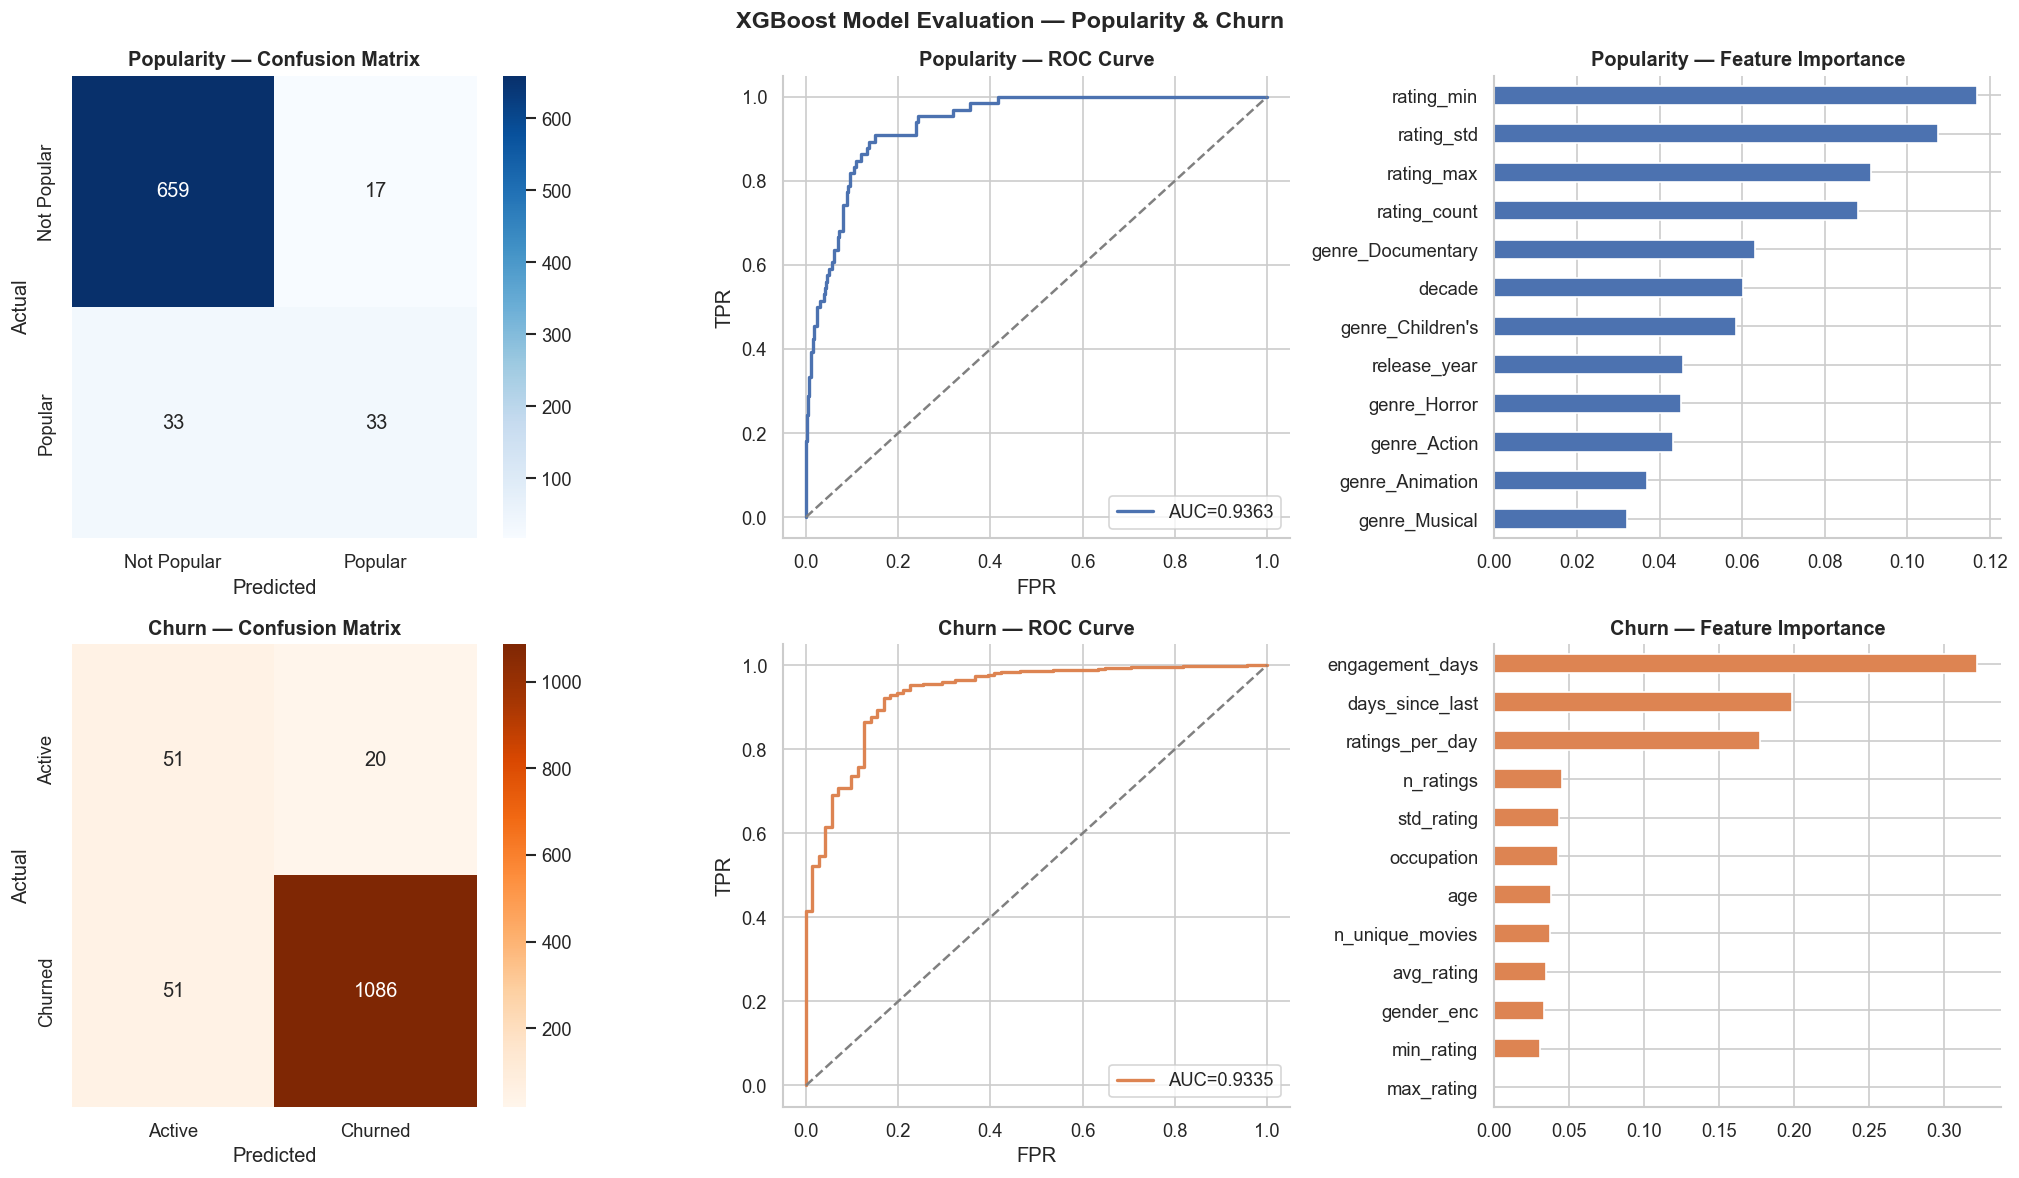

Saved: plot_xgb_evaluation.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# ── Row 1: Popularity ────────────────────────────────────────────────────
# Confusion matrix
cm_pop = confusion_matrix(y_pop_te, y_pop_pred)
sns.heatmap(cm_pop, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Not Popular','Popular'],
            yticklabels=['Not Popular','Popular'])
axes[0,0].set_title('Popularity — Confusion Matrix', fontweight='bold')
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('Actual')

# ROC
fpr_p, tpr_p, _ = roc_curve(y_pop_te, y_pop_pred_prob)
axes[0,1].plot(fpr_p, tpr_p, color='#4C72B0', lw=2, label=f'AUC={pop_auc:.4f}')
axes[0,1].plot([0,1],[0,1],'--', color='gray')
axes[0,1].set_title('Popularity — ROC Curve', fontweight='bold')
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
axes[0,1].legend(); axes[0,1].spines[['top','right']].set_visible(False)

# Feature importance
fi_pop = pd.Series(pop_model.feature_importances_, index=POP_FEATURES).sort_values(ascending=True).tail(12)
fi_pop.plot(kind='barh', ax=axes[0,2], color='#4C72B0')
axes[0,2].set_title('Popularity — Feature Importance', fontweight='bold')
axes[0,2].spines[['top','right']].set_visible(False)

# ── Row 2: Churn ─────────────────────────────────────────────────────────
cm_ch = confusion_matrix(y_ch_te, y_ch_pred)
sns.heatmap(cm_ch, annot=True, fmt='d', cmap='Oranges', ax=axes[1,0],
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
axes[1,0].set_title('Churn — Confusion Matrix', fontweight='bold')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')

fpr_c, tpr_c, _ = roc_curve(y_ch_te, y_ch_pred_prob)
axes[1,1].plot(fpr_c, tpr_c, color='#DD8452', lw=2, label=f'AUC={churn_auc:.4f}')
axes[1,1].plot([0,1],[0,1],'--', color='gray')
axes[1,1].set_title('Churn — ROC Curve', fontweight='bold')
axes[1,1].set_xlabel('FPR'); axes[1,1].set_ylabel('TPR')
axes[1,1].legend(); axes[1,1].spines[['top','right']].set_visible(False)

fi_ch = pd.Series(churn_model.feature_importances_, index=CHURN_FEATURES).sort_values(ascending=True)
fi_ch.plot(kind='barh', ax=axes[1,2], color='#DD8452')
axes[1,2].set_title('Churn — Feature Importance', fontweight='bold')
axes[1,2].spines[['top','right']].set_visible(False)

plt.suptitle('XGBoost Model Evaluation — Popularity & Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_xgb_evaluation.png', bbox_inches='tight')
plt.show()
print('Saved: plot_xgb_evaluation.png')

---
## 5. Churn Risk Segments

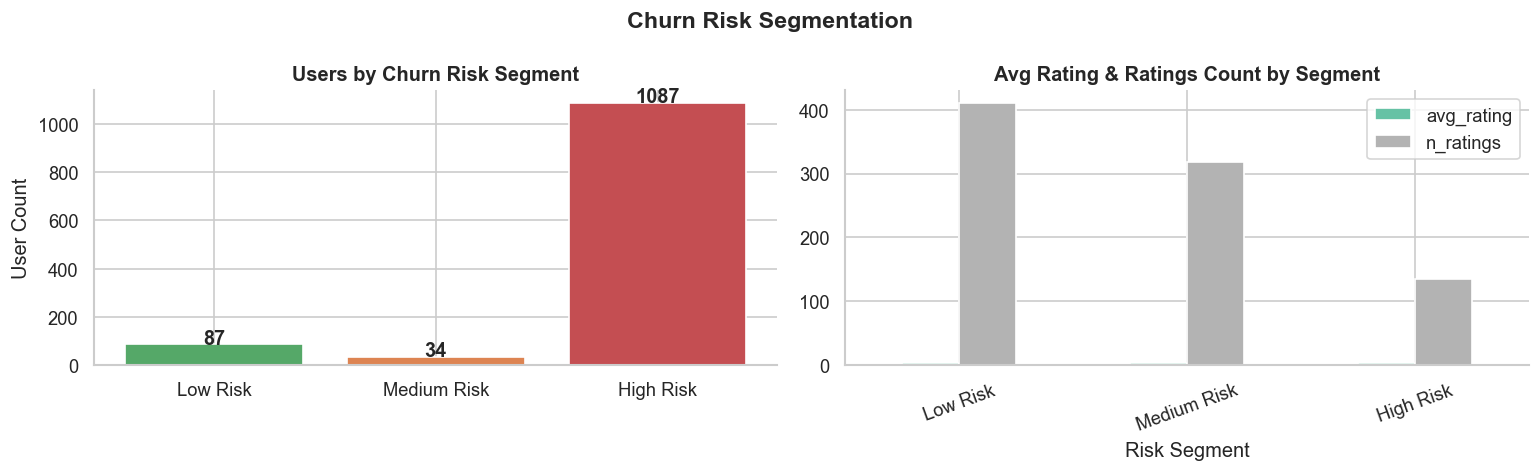

Saved: plot_churn_segments.png


In [10]:
user_feat_te = user_feat.iloc[X_ch_te.index].copy()
user_feat_te['churn_prob'] = y_ch_pred_prob
user_feat_te['risk_segment'] = pd.cut(
    user_feat_te['churn_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

seg_counts = user_feat_te['risk_segment'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#55A868', '#DD8452', '#C44E52']
axes[0].bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Users by Churn Risk Segment', fontsize=12, fontweight='bold')
axes[0].set_ylabel('User Count')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

seg_avg = user_feat_te.groupby('risk_segment')[['avg_rating','n_ratings','days_since_last']].mean()
seg_avg[['avg_rating','n_ratings']].plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Avg Rating & Ratings Count by Segment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Segment'); axes[1].tick_params(axis='x', rotation=20)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Churn Risk Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_churn_segments.png', bbox_inches='tight')
plt.show()
print('Saved: plot_churn_segments.png')

---
## 6. Popularity Score Distribution

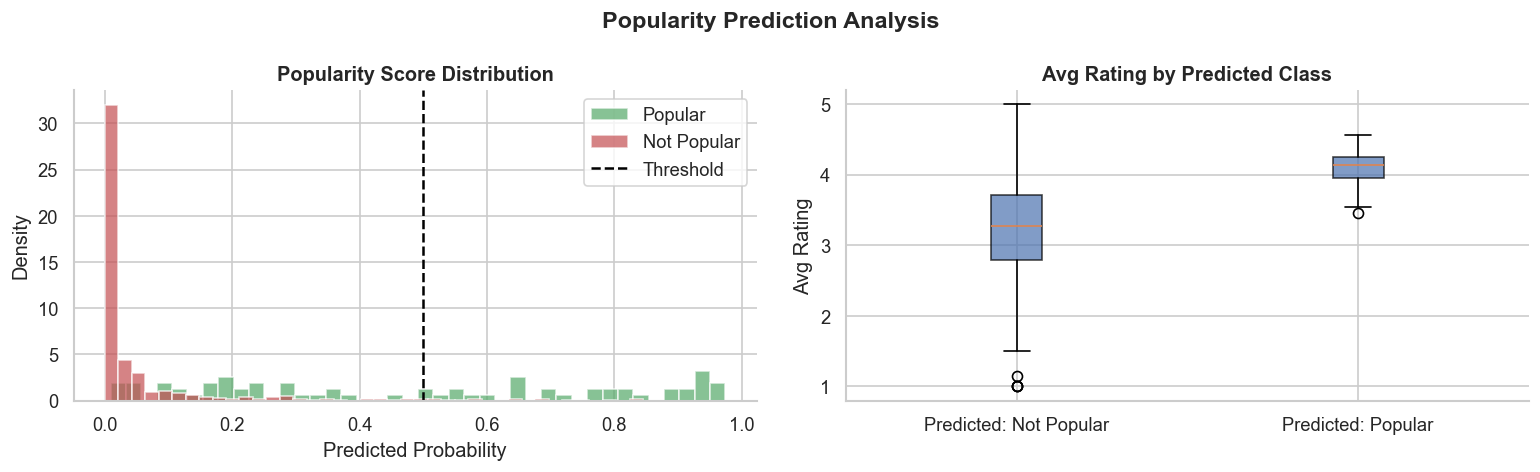

Saved: plot_popularity_analysis.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_pop_pred_prob[y_pop_te == 1], bins=40, alpha=0.7,
             color='#55A868', label='Popular', density=True)
axes[0].hist(y_pop_pred_prob[y_pop_te == 0], bins=40, alpha=0.7,
             color='#C44E52', label='Not Popular', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold')
axes[0].set_title('Popularity Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Probability'); axes[0].set_ylabel('Density')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

# Avg rating by predicted popularity
movie_agg_te = movie_agg.iloc[X_pop_te.index].copy()
movie_agg_te['pred_popular'] = y_pop_pred
bp_data = [movie_agg_te.loc[movie_agg_te['pred_popular'] == 0, 'avg_rating'],
           movie_agg_te.loc[movie_agg_te['pred_popular'] == 1, 'avg_rating']]
axes[1].boxplot(bp_data, labels=['Predicted: Not Popular', 'Predicted: Popular'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_title('Avg Rating by Predicted Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Rating')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Popularity Prediction Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/plot_popularity_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: plot_popularity_analysis.png')

---
## 7. Save Metrics & Feature Importance for Dashboard

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'popularity': {
        'accuracy':  round(float(pop_acc),  4),
        'roc_auc':   round(float(pop_auc),  4),
        'precision': round(float(precision_score(y_pop_te, y_pop_pred)), 4),
        'recall':    round(float(recall_score(y_pop_te, y_pop_pred)),    4),
        'f1':        round(float(f1_score(y_pop_te, y_pop_pred)),        4)
    },
    'churn': {
        'accuracy':  round(float(churn_acc), 4),
        'roc_auc':   round(float(churn_auc), 4),
        'precision': round(float(precision_score(y_ch_te, y_ch_pred)), 4),
        'recall':    round(float(recall_score(y_ch_te, y_ch_pred)),    4),
        'f1':        round(float(f1_score(y_ch_te, y_ch_pred)),        4)
    }
}

with open(f'{PROCESSED_DIR}/xgb_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Metrics saved:')
print(json.dumps(metrics, indent=2))

# Feature importance tables
fi_pop_df = pd.DataFrame({'feature': POP_FEATURES,
                          'importance': pop_model.feature_importances_}
                        ).sort_values('importance', ascending=False)
fi_ch_df  = pd.DataFrame({'feature': CHURN_FEATURES,
                          'importance': churn_model.feature_importances_}
                        ).sort_values('importance', ascending=False)

fi_pop_df.to_csv(f'{PROCESSED_DIR}/pop_feature_importance.csv',   index=False)
fi_ch_df.to_csv(f'{PROCESSED_DIR}/churn_feature_importance.csv',  index=False)
print('Feature importance tables saved.')
print('\nTop 5 Popularity Features:')
print(fi_pop_df.head())
print('\nTop 5 Churn Features:')
print(fi_ch_df.head())

Metrics saved:
{
  "popularity": {
    "accuracy": 0.9326,
    "roc_auc": 0.9363,
    "precision": 0.66,
    "recall": 0.5,
    "f1": 0.569
  },
  "churn": {
    "accuracy": 0.9412,
    "roc_auc": 0.9335,
    "precision": 0.9819,
    "recall": 0.9551,
    "f1": 0.9683
  }
}
Feature importance tables saved.

Top 5 Popularity Features:
              feature  importance
2          rating_min    0.116911
1          rating_std    0.107403
3          rating_max    0.091127
0        rating_count    0.088008
17  genre_Documentary    0.063029

Top 5 Churn Features:
           feature  importance
6  engagement_days    0.321865
7  days_since_last    0.198344
8  ratings_per_day    0.176801
0        n_ratings    0.045441
2       std_rating    0.043027


---
## Summary

| Task | Model | Target | Saved File |
|---|---|---|---|
| Movie Popularity | XGBoost Classifier | avg_rating ≥ 4.0 & ≥50 ratings | `models/xgb_popularity.pkl` |
| User Churn | XGBoost Classifier | no activity in last 20% of window | `models/xgb_churn.pkl` |
| Metrics | Accuracy, AUC, F1 | both tasks | `processed/xgb_metrics.json` |

**Next: Run 05_Genre_Classification.ipynb**

In [13]:
# ======================================================================
# BUG FIX: Popularity Model Threshold Tuning
# Root cause: default 0.5 threshold wrong for 8.9% positive imbalanced data.
# Fix: Youden's J statistic to pick optimal threshold from ROC curve.
# ======================================================================
from sklearn.metrics import roc_curve, precision_score, recall_score, f1_score, accuracy_score, classification_report
import numpy as np
import json as _json

fpr_p2, tpr_p2, thresholds_p2 = roc_curve(y_pop_te, y_pop_pred_prob)

# Youden J = TPR - FPR; pick the threshold that maximises it
youden_j = tpr_p2 - fpr_p2
optimal_idx = int(np.argmax(youden_j))
optimal_threshold = float(thresholds_p2[optimal_idx])
print(f'Optimal threshold (Youden J): {optimal_threshold:.4f}  (default was 0.5)')

y_pop_pred_fixed = (y_pop_pred_prob >= optimal_threshold).astype(int)

pop_acc_fixed  = accuracy_score(y_pop_te, y_pop_pred_fixed)
pop_prec_fixed = precision_score(y_pop_te, y_pop_pred_fixed, zero_division=0)
pop_rec_fixed  = recall_score(y_pop_te,  y_pop_pred_fixed, zero_division=0)
pop_f1_fixed   = f1_score(y_pop_te,      y_pop_pred_fixed, zero_division=0)

print()
print('[FIXED] Popularity Model:')
print(f'  Accuracy  : {pop_acc_fixed:.4f}  (was {pop_acc:.4f})')
print(f'  Precision : {pop_prec_fixed:.4f}')
print(f'  Recall    : {pop_rec_fixed:.4f}')
print(f'  F1        : {pop_f1_fixed:.4f}  (was 0.5690)')
print()
print(classification_report(y_pop_te, y_pop_pred_fixed, target_names=['Not Popular', 'Popular']))

# Update saved metrics JSON
metrics_path = f'{PROCESSED_DIR}/xgb_metrics.json'
with open(metrics_path) as _f:
    _saved = _json.load(_f)
_saved['popularity'].update({
    'accuracy':          round(float(pop_acc_fixed),  4),
    'precision':         round(float(pop_prec_fixed), 4),
    'recall':            round(float(pop_rec_fixed),  4),
    'f1':                round(float(pop_f1_fixed),   4),
    'optimal_threshold': round(optimal_threshold,     4),
    'threshold_method':  'youden_j',
})
with open(metrics_path, 'w') as _f:
    _json.dump(_saved, _f, indent=2)
print('Updated xgb_metrics.json saved.')
print(_json.dumps(_saved, indent=2))


Optimal threshold (Youden J): 0.0854  (default was 0.5)

[FIXED] Popularity Model:
  Accuracy  : 0.8558  (was 0.9326)
  Precision : 0.3727
  Recall    : 0.9091
  F1        : 0.5286  (was 0.5690)

              precision    recall  f1-score   support

 Not Popular       0.99      0.85      0.91       676
     Popular       0.37      0.91      0.53        66

    accuracy                           0.86       742
   macro avg       0.68      0.88      0.72       742
weighted avg       0.93      0.86      0.88       742

Updated xgb_metrics.json saved.
{
  "popularity": {
    "accuracy": 0.8558,
    "roc_auc": 0.9363,
    "precision": 0.3727,
    "recall": 0.9091,
    "f1": 0.5286,
    "optimal_threshold": 0.0854,
    "threshold_method": "youden_j"
  },
  "churn": {
    "accuracy": 0.9412,
    "roc_auc": 0.9335,
    "precision": 0.9819,
    "recall": 0.9551,
    "f1": 0.9683
  }
}
